In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans

sns.set(style='whitegrid')

In [20]:
dataset=pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [21]:
x = dataset.iloc[:, [3,4]].values

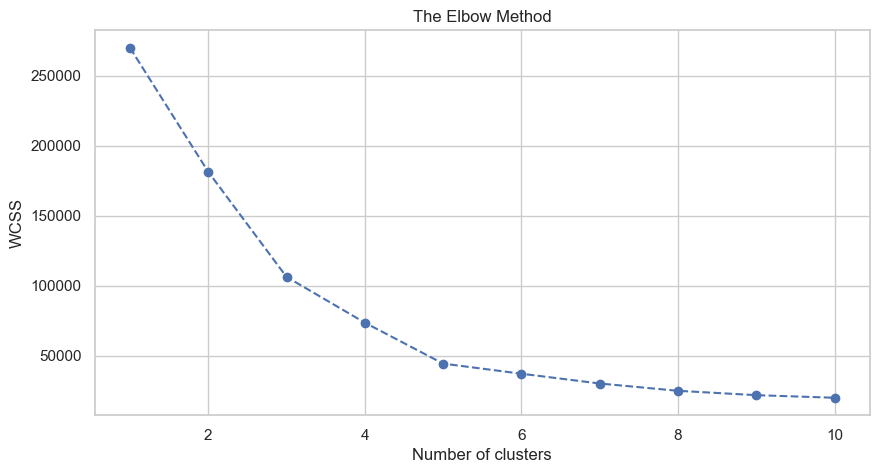

In [22]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x)

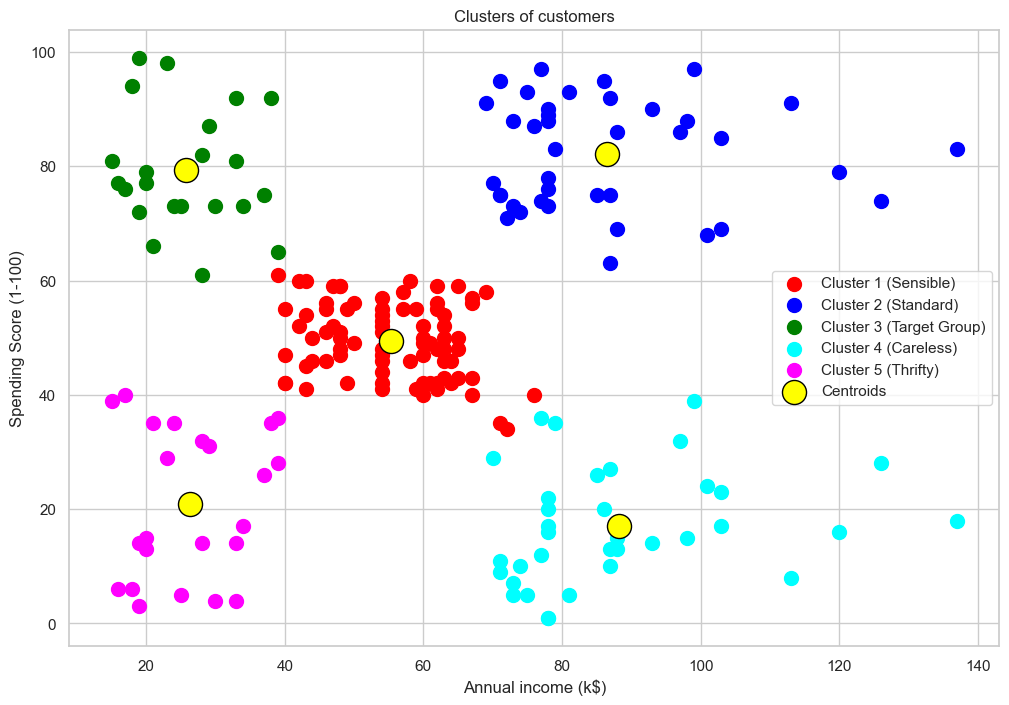

In [24]:
plt.figure(figsize=(12, 8))
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Sensible)')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (Standard)')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2,1], s=100, c='green', label='Cluster 3 (Target Group)')
plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4 (Careless)')
plt.scatter(x[y_kmeans == 4, 0], x[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5 (Thrifty)')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of customers')
plt.xlabel('Annual income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [28]:
def classify_customer():
   try:
      print("---MARKET SEGMENTATION TOOL---")
      income=int(input("Enter annual income in k$ (eg.30): "))
      spending=int(input("Enter spending score 1-100 (eg.20): "))
      cluster=kmeans.predict([[income, spending]])[0]


      cluster_names={
              0: "Sensible(high income, low spent)",
              1: "Standard(Average income ,average spent)",
              2: "Target/Premium(High income,high spent)",
              3: "Careless(low income,high spend)",
              4: "Careful(low income,low spend)"
      }

      print("\n" + "-" * 40)
      print(f"Result: This customer belongs to group {cluster + 1}")
      print(f"Segment: {cluster_names[cluster]}")
      print("-" * 40)
   except ValueError:
      print("invalid input")




classify_customer()
        
        
        
      
       

---MARKET SEGMENTATION TOOL---

----------------------------------------
Result: This customer belongs to group 5
Segment: Careful(low income,low spend)
----------------------------------------
